# CS 378 Systems for Machine Learning - Assignment 0: PyTorch & Profiling

Welcome to Assignment 0! The goal of this assignment is to give you a warm-up exercise on PyTorch, a powerful tool for building modern AI workloads, especially if you have no prior experience with it. The assignment consists of the following parts:

1. **PyTorch Fundamentals:** You will learn how to train a simple MLP model that classifies handwritten digits. You will implement the core operators of this neural network by hand, including both their **forward** and **backward** (gradient) passes, and then assemble them into an MLP model. You will also implement the training loop and eventually train your model to achieve high accuracy.
2. **The PyTorch Profiler:** You will learn how to profile your code with `torch.profiler`, which reveals the underlying activities on the hardware and gives you a systems lens for understanding the performance of your code.


Note that we have provided some skeleton code in this notebook. Make sure you complete the code blocks between `# TODO: ...` and `# END OF YOUR CODE` before handing in the assignment.

You need to submit a seperate report answering all the questions 
.


# Before You Start

This assignment is designed to run on **Google Colab**, which gives you free access to a GPU. Profiling (Part 2) is far more interesting on a GPU, so please connect to one before you begin:

1. Open this notebook in Colab (**File → Open notebook**, or upload the `.ipynb`).
2. In the top menu, go to **Runtime → Change runtime type**.
3. Under **Hardware accelerator**, select **GPU** (a free **T4** is more than enough for this assignment), then click **Save**.
4. Click **Connect** in the top-right corner to attach to the runtime.

You can confirm the GPU is active by running the **Setup** cell below: it prints the device it will use. You should see `Using device: cuda`. If it prints `cpu`, revisit the steps above.

> **Note:** The code will still run on CPU, but training and profiling will be noticeably slower, and some GPU-only parts will be skipped. We strongly recommend using a GPU runtime.


## Setup

`torch` and `torchvision` are pre-installed on Colab. If you are running
elsewhere and they are missing, uncomment the line below.


In [ ]:
# !pip install torch torchvision matplotlib  # (already present on Colab)

import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt


SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("Using device   :", device)


## Load the MNIST Dataset

MNIST is 70,000 grayscale images (28×28) of handwritten digits 0–9,
split into 60,000 training and 10,000 test images. We normalize pixels with the
standard MNIST mean/std so training is well-behaved.


In [ ]:
from torchvision import datasets, transforms

# ToTensor -> [0,1] float tensor of shape (1, 28, 28); Normalize -> ~zero-mean.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_set = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_set  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

print("Train images:", len(train_set))
print("Test  images:", len(test_set))


In [ ]:
# Visualization: a few example digits and their labels.
example_loader = DataLoader(train_set, batch_size=8, shuffle=True)
examples, labels = next(iter(example_loader))
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(examples[i, 0], cmap="gray")
    ax.set_title(f"label: {labels[i].item()}")
    ax.axis("off")
plt.suptitle("Sample MNIST digits")
plt.tight_layout()
plt.show()


# Part 1: PyTorch Fundamentals

In this part you will:
- Implement the operators of an MLP model.
- Assemble the operators into an MLP classifier.
- Write the training loop.
- Train the MLP classifier on the MNIST dataset.


> If this is the first time you work with tensors, neural networks and deep learning, here is [a nice 60-minute tutorial](https://docs.pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html) offered by PyTorch you can go through first. PyTorch documentation is your best friend when learning it!



## Operators

A neural network is built from a handful of small **operators**. In this section you will implement three of them — **Linear**, **ReLU**, and **Cross-Entropy** — completely from scratch.

Each operator is written as a `torch.autograd.Function`, which requires you to define two methods:

- `forward(ctx, ...)`: computes the output from the inputs. It also stashes any tensors it will need later by calling `ctx.save_for_backward(...)`.
- `backward(ctx, grad_output)`: given the gradient of the loss with respect to this op's **output** (`grad_output`), returns the gradient of the loss with respect to each **input**, using the chain rule.

Implementing `backward` by hand is the whole point: it forces you to understand exactly how gradients flow through each operator, which is the foundation of neural networks.

For each operator we (1) implement forward + backward by hand, then (2) check it against PyTorch's built-in version — **both the output value and the gradients must match**. We use two independent checks:

- `torch.autograd.gradcheck`: numerically perturbs each input by a tiny amount and compares the resulting *numerical* gradient to your *analytic* `backward` (run in `float64` for precision).
- `torch.allclose` vs. `torch.nn.functional`: confirms your op agrees with PyTorch's reference implementation.


### The Linear Operator

For input $x \in \mathbb{R}^{N\times \text{in}}$, weight
$W \in \mathbb{R}^{\text{out}\times \text{in}}$, bias $b\in\mathbb{R}^{\text{out}}$
(where $N$ is the number of examples in the batch, and $\text{in}$/$\text{out}$ are the
input/output feature dimensions):

$$y = xW^\top + b$$

Given $g = \dfrac{\partial L}{\partial y}$ (shape $N\times\text{out}$), the chain rule gives:

$$\frac{\partial L}{\partial x} = gW,\qquad
  \frac{\partial L}{\partial W} = g^\top x,\qquad
  \frac{\partial L}{\partial b} = \sum_{n} g_n$$

In [ ]:
class LinearFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, weight, bias):
        ###############################################################################
        # TODO: Implement the forward pass                                            #
        ###############################################################################
        # Hint: Save any tensors backward will need via `ctx.save_for_backward(a, b, c)`


        ################################################################################
        #                                 END OF YOUR CODE                             #
        ################################################################################
        return output

    @staticmethod
    def backward(ctx, grad_output):
        ###############################################################################
        # TODO: Implement the backward pass                                           #
        ###############################################################################
        # Hint: Retrieve saved tensors via `a, b, c = ctx.saved_tensors`


        ################################################################################
        #                                 END OF YOUR CODE                             #
        ################################################################################
        return grad_x, grad_weight, grad_bias

my_linear = LinearFunction.apply


Before proceeding, make sure you pass the sanity check:

In [ ]:
torch.manual_seed(0)
N, D_in, D_out = 4, 5, 3
x = torch.randn(N, D_in, dtype=torch.double, requires_grad=True)
W = torch.randn(D_out, D_in, dtype=torch.double, requires_grad=True)
b = torch.randn(D_out,       dtype=torch.double, requires_grad=True)

# 1) gradcheck: analytic backward vs. numerical gradient
assert torch.autograd.gradcheck(my_linear, (x, W, b)), "Linear gradcheck failed"

# 2) forward + gradients match torch.nn.functional.linear
y_mine = my_linear(x, W, b)
y_ref  = F.linear(x, W, b)
assert torch.allclose(y_mine, y_ref), "Linear forward mismatch"

y_mine.sum().backward()
gx, gW, gb = x.grad.clone(), W.grad.clone(), b.grad.clone()
x.grad = W.grad = b.grad = None
F.linear(x, W, b).sum().backward()
assert torch.allclose(gx, x.grad) and torch.allclose(gW, W.grad) and torch.allclose(gb, b.grad), \
    "Linear gradient mismatch"
print("Linear operator checks passed ✔")


### The ReLU Operator

ReLU zeroes out negative values and passes positive values through unchanged,
applied elementwise:

$$y = \mathrm{ReLU}(x) = \max(x, 0)$$

Given $g = \dfrac{\partial L}{\partial y}$, its gradient is 1 where the input was
positive and 0 elsewhere:

$$\frac{\partial L}{\partial x} = g \odot \mathbb{1}[x > 0]$$

In [ ]:
class ReLUFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        ###############################################################################
        # TODO: Implement the forward pass                                            #
        ###############################################################################
        # Hint: Save any tensors backward will need via `ctx.save_for_backward(a, b, c)`


        ################################################################################
        #                                 END OF YOUR CODE                             #
        ################################################################################
        return output

    @staticmethod
    def backward(ctx, grad_output):
        ###############################################################################
        # TODO: Implement the backward pass                                           #
        ###############################################################################
        # Hint: Retrieve saved tensors via `a, b, c = ctx.saved_tensors`


        ################################################################################
        #                                 END OF YOUR CODE                             #
        ################################################################################
        return grad_x

my_relu = ReLUFunction.apply


Before proceeding, make sure you pass the sanity check:

In [ ]:
torch.manual_seed(0)
x = torch.randn(4, 5, dtype=torch.double, requires_grad=True)
assert torch.autograd.gradcheck(my_relu, (x,)), "ReLU gradcheck failed"
assert torch.allclose(my_relu(x), F.relu(x)), "ReLU forward mismatch"
print("ReLU operator checks passed ✔")


### The Cross-Entropy Loss

The classifier outputs raw scores ("logits") $z \in \mathbb{R}^{N\times C}$,
where $N$ is the number of examples in the batch and $C$ is the number of classes.
The entry $z_{n,c}$ is the score the model assigns to class $c$ for the $n$-th
example (a larger value means the model favors that class), and $t_n \in \{0,\dots,C-1\}$
is the true label of example $n$.
Cross-entropy first turns each row of scores into probabilities with **softmax**, then
measures the negative log-probability of the correct class $t_n$:

$$p_{n,c} = \mathrm{softmax}(z)_{n,c} = \frac{\exp(z_{n,c})}{\sum_{j=1}^{C}\exp(z_{n,j})},\qquad L = -\frac{1}{N}\sum_{n}\log p_{n, t_n}$$

In practice we work with the **log-probabilities** directly, computing them in a
numerically stable way: subtract each row's max $m_n=\max_{j} z_{n,j}$ before `exp`,
which leaves the result unchanged but keeps `exp` from overflowing:

$$\log p_{n,c} = (z_{n,c}-m_n) - \log\!\sum_{j=1}^{C}\exp(z_{n,j}-m_n),\qquad m_n=\max_{j} z_{n,j}$$

The gradient has a famously clean form:

$$\frac{\partial L}{\partial z} = \frac{1}{N}\,(p - \text{onehot}(t))$$


In [ ]:
class CrossEntropyFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, logits, target):
        ###############################################################################
        # TODO: Implement the forward pass                                            #
        ###############################################################################
        # Hint: Save any tensors backward will need via `ctx.save_for_backward(a, b, c)`


        ################################################################################
        #                                 END OF YOUR CODE                             #
        ################################################################################
        return loss

    @staticmethod
    def backward(ctx, grad_output):
        ###############################################################################
        # TODO: Implement the backward pass                                           #
        ###############################################################################
        # Hint: Retrieve saved tensors via `a, b, c = ctx.saved_tensors`


        ################################################################################
        #                                 END OF YOUR CODE                             #
        ################################################################################
        # Note that `target` is frozen ground truth, not the differentiable parameters
        # We return `None` for the grad of `target`
        return grad_logits, None

my_cross_entropy = CrossEntropyFunction.apply


Before proceeding, make sure you pass the sanity check:

In [ ]:
torch.manual_seed(0)
N, C = 6, 4
logits = torch.randn(N, C, dtype=torch.double, requires_grad=True)
target = torch.randint(0, C, (N,))

# gradcheck only differentiates w.r.t. the float input (logits).
assert torch.autograd.gradcheck(lambda z: my_cross_entropy(z, target), (logits,)), \
    "CrossEntropy gradcheck failed"

loss_mine = my_cross_entropy(logits, target)
loss_ref  = F.cross_entropy(logits, target)
assert torch.allclose(loss_mine, loss_ref), "CrossEntropy forward mismatch"

loss_mine.backward()
g_mine = logits.grad.clone(); logits.grad = None
F.cross_entropy(logits, target).backward()
assert torch.allclose(g_mine, logits.grad), "CrossEntropy gradient mismatch"
print("CrossEntropy operator checks passed ✔")


## The MLP Classifier

Now we assemble the operators into a **Multi-Layer Perceptron (MLP)**. Each
image (28×28 = 784 pixels) is flattened into a vector, passed through a hidden
`Linear → ReLU` block, and then a final `Linear` layer produces 10 logits (one
per digit).

We wrap our `LinearFunction` in a small `nn.Module` (`MyLinear`) so its weight
and bias are registered as **learnable parameters** (`nn.Parameter`) that the
optimizer can update.


In [ ]:
class MyLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias   = nn.Parameter(torch.empty(out_features))
        # Standard init: uniform on +/- 1/sqrt(fan_in).
        bound = 1.0 / (in_features ** 0.5)
        nn.init.uniform_(self.weight, -bound, bound)
        nn.init.uniform_(self.bias,   -bound, bound)

    def forward(self, x):
        ###############################################################################
        # TODO: Apply your LinearFunction to x using this layer's weight and bias.    #
        ###############################################################################


        ################################################################################
        #                                 END OF YOUR CODE                             #
        ################################################################################
        return output
        # During backward, autograd will automatically call LinearFunction.backward.


class MLP(nn.Module):
    def __init__(self, hidden, in_dim=784, num_classes=10):
        super().__init__()
        self.fc1 = MyLinear(in_dim, hidden)
        self.fc2 = MyLinear(hidden, num_classes)

    def forward(self, x):
        ###############################################################################
        # TODO: Implement the forward pass of MLP.                                    #
        ###############################################################################
        # Hint: Flatten the image, then fc1 -> ReLU -> fc2 to produce logits.


        ################################################################################
        #                                 END OF YOUR CODE                             #
        ################################################################################
        return logits


Before proceeding, make sure your MLP model outputs the right shape of logits:

In [ ]:
model = MLP(hidden=64).to(device) # for this test we set the hidden dim as 64
xb, yb = next(iter(example_loader))
out = model(xb.to(device))
assert out.shape == (xb.shape[0], 10), f"expected (N,10) logits, got {out.shape}"

print(f"MLP output shape: {tuple(out.shape)}")
print("MLP structure checks passed ✔")


### Question 1

How many trainable parameters are there in this MLP model when `hidden_dim=64`? By default PyTorch uses 32-bit floating point number for the parameters. How much memory (in KB) do we need to store the parameter tensors? Show each step of your calculation process. *Note: reporting just a correct number is only worth half of the points.*

> Hint: You can print `sum(p.numel() for p in model.parameters())` to check if your calculation of parameter number is correct

## The Training Loop

Time to train. The training loop is the heart of almost every ML system, and you
will see this same pattern for all kinds of models. For each batch of images, we:

1. **move data to the device**: copy the batch to the GPU (when one is available)
2. **forward + loss**: compute the logits, then the cross-entropy loss against the true labels
3. **reset gradients**: the optimizer clears the gradients left over from the previous step
4. **backward**: `loss.backward()` triggers PyTorch's autograd engine to compute the gradient of every parameter, using
   the manual `backward` methods you wrote above
5. **optimizer step**: the optimizer updates the parameters


In [ ]:
def make_optimizer(name, params, lr):
    # Factory that maps a string name to a configured PyTorch optimizer.
    name = name.lower()
    if name == "sgd":     return torch.optim.SGD(params, lr=lr)
    if name == "adam":    return torch.optim.Adam(params, lr=lr)
    if name == "adamw":   return torch.optim.AdamW(params, lr=lr)
    if name == "rmsprop": return torch.optim.RMSprop(params, lr=lr)
    raise ValueError(f"unknown optimizer: {name!r}")


@torch.no_grad()  # no gradients needed during evaluation
def evaluate(model, loader):
    model.eval()
    correct = total = 0
    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)
        preds = model(images).argmax(dim=1)          # predicted class = argmax over logits
        correct += (preds == targets).sum().item()
        total   += targets.numel()
    return correct / total


def run_train(hidden_dim, batch_size, optim_method, lr, epochs=3):
    torch.manual_seed(SEED)
    label = f"{optim_method}, lr={lr:g}, h={hidden_dim}, bs={batch_size}, epochs={epochs}"

    # Load the data for training and evaluation
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_set,  batch_size=1000,       shuffle=False)

    # Init the MLP model
    model = MLP(hidden=hidden_dim).to(device)

    # Init the optimizer
    optimizer = make_optimizer(optim_method, model.parameters(), lr)

    # Training loop
    print(f"-------- {label} --------")
    history = {"label": label, "step_loss": [], "test_acc": []}

    for epoch in range(epochs):
        model.train()
        running = 0.0

        for i, (images, targets) in enumerate(train_loader):
            ###############################################################################
            # TODO: Implement one training step.                                          #
            ###############################################################################
            # step 1: move the batch to the device


            # step 2: forward pass + loss computation


            # step 3: reset gradients


            # step 4: backward pass


            # step 5: optimizer step


            ################################################################################
            #                                 END OF YOUR CODE                             #
            ################################################################################

            # logging
            running += loss.item()
            history["step_loss"].append(loss.item())
            if (i + 1) % 100 == 0:
                print(f"epoch {epoch+1} | step {i+1:4d}/{len(train_loader)} | "
                      f"loss {running/100:.4f}")
                running = 0.0


        # evaluate on the test set at the end of each epoch
        acc = evaluate(model, test_loader)
        history["test_acc"].append(acc)
        print(f"==> epoch {epoch+1} test accuracy: {acc*100:.2f}%")

    return history

We provide a helper function that plots the loss curves from a set of training histories.

In [ ]:
def plot_histories(histories):
    '''Overlay per-step loss and per-epoch test accuracy for several runs.'''
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    for h in histories:
        ax1.plot(h["step_loss"], alpha=0.8, label=h["label"])
        ax2.plot(range(1, len(h["test_acc"]) + 1),
                 [a * 100 for a in h["test_acc"]], marker="o", label=h["label"])
    ax1.set_xlabel("training step"); ax1.set_ylabel("loss"); ax1.set_title("Training loss")
    ax2.set_xlabel("epoch"); ax2.set_ylabel("test accuracy (%)"); ax2.set_title("Test accuracy")
    ax1.legend(fontsize=8); ax2.legend(fontsize=8)
    plt.tight_layout(); plt.show()

## Train Your MLP

The training loop accepts the following parameters:
- `hidden_dim`: the hidden dimension size of your MLP model
- `batch_size`: the number of samples in a batch for one optimizer update
- `optim_method`: the optimizer you choose (`"sgd"`, `"adam"`, `"adamw"`, or `"rmsprop"`)
- `lr`: the learning rate
- `epochs`: the number of epochs (full passes over the training set) to run

**Your goal is to find a combination of these parameters that yields a test accuracy > 97%.** You will need to report the choices of parameters.

Below is an example of how to run your training loop with a few different choices of optimizer. If your implementation is correct, you should already see a test accuracy above 91%.


In [ ]:
histories = [run_train(hidden_dim=16, batch_size=128, optim_method=o, lr=1e-3, epochs=1) for o in ["sgd", "rmsprop", "adam"]]
plot_histories(histories)

### Question 2

Report the recipe of training parameters (`hidden_dim`, `batch_size`, `optim_method`, `lr`, `epochs`) that achieves a final test accuracy **> 97%**, and attach the loss curve produced by `plot_histories` for that run.


# Part 2: Profiling Your Code

In this part you will:
- Profile your training loop with `torch.profiler`.
- Visualize and read the recorded trace and memory timeline.
- Analyze how different parameters change the performance.

## Profiler setup

[PyTorch Profiler](https://docs.pytorch.org/docs/2.13/profiler.html) is a profiling tool that collects performance metrics during the execution of PyTorch code. Key knobs we turn on:
- **`activities`**: record CPU ops (and CUDA/GPU ops when a GPU is available).
- **`schedule`**: skip the first steps (`wait`/`warmup`) so one-time setup costs
  don't pollute the measurement, then record a few `active` steps.
- **`record_shapes`**: remember the tensor shapes each op saw.
- **`profile_memory`**: track tensor memory allocations.
- **`with_stack`**: remember the Python source line behind each op.

We also wrap regions of the step with **`record_function(...)`** labels
(`h2d`, `forward`, `clear grad`, `backward`, `optimizer`) so we can see how the step-time
splits across those phases.

Note that by default we run 5 steps of the training loop and include the initial warm-up steps in the profiling (the schedule is `wait=0, warmup=0` on purpose), so that you can observe the entire trace both at the initialization stage, where operations are significantly slower, and at the steady stage later on.

In [ ]:
from torch.profiler import profile, record_function, ProfilerActivity, schedule


def run_profile(hidden_dim, batch_size, optim_method, n_step=5):
  label = f"{optim_method}_h={hidden_dim}_bs={batch_size}"

  # Record CPU ops always; also record CUDA/GPU ops when a GPU is present.
  activities = [ProfilerActivity.CPU]
  if torch.cuda.is_available():
      activities.append(ProfilerActivity.CUDA)

  # schedule() controls which steps are actually recorded:
  prof_schedule = schedule(wait=0, warmup=0, active=n_step, repeat=1)

  model = MLP(hidden=hidden_dim).to(device)
  optimizer = make_optimizer(optim_method, model.parameters(), lr=1e-3)

  # Use random data so we profile compute, not the MNIST data pipeline.
  images_host  = torch.randn(batch_size, 1, 28, 28)   # stays on CPU (host)
  targets_host = torch.randint(0, 10, (batch_size,))  # stays on CPU (host)

  model.train()

  # GPU kernels launch asynchronously; synchronize so earlier work doesn't
  # bleed into the region we are about to profile.
  if torch.cuda.is_available():
      torch.cuda.synchronize()

  with profile(activities=activities, schedule=prof_schedule,
              record_shapes=True, profile_memory=True, with_stack=True) as prof:

      for step in range(n_step):
          # Each record_function(...) block becomes a named slice in the trace,
          # so we can see how much time each phase of the step takes.
          ###############################################################################
          # TODO: Wrap your training loop code in Part 1 with proper recording tag.     #
          ###############################################################################
          with record_function("h2d"):
              # step 1: move the batch from host to the device


          with record_function("forward"):
              # step 2: forward pass + loss computation


          with record_function("clear grad"):
              # step 3: reset the gradients


          with record_function("backward"):
              # step 4: backward pass


          with record_function("optimizer"):
              # step 5: optimizer step


          ################################################################################
          #                                 END OF YOUR CODE                             #
          ################################################################################
          # Wait for all queued GPU work to complete before next step
          if torch.cuda.is_available():
              torch.cuda.synchronize()

          prof.step()   # tell the profiler a step finished

  print("Profiling complete.")


  # Export a trace of the recorded steps.
  trace_path = f"{label}_trace.json"
  prof.export_chrome_trace(trace_path)
  print(f"Wrote {trace_path}")

  # Optional: richer CUDA memory-over-time timeline (GPU only).
  if torch.cuda.is_available():
      try:
          prof.export_memory_timeline(f"{label}_memory.html", device="cuda:0")
          print(f"Wrote {label}_memory.html")
      except Exception as e:
          print("memory timeline export skipped:", e)

  # On Colab, trigger a download so you can open the trace locally.
  try:
      from google.colab import files  # type: ignore
      files.download(trace_path)
  except Exception:
      print("(not on Colab — find the trace file in the file browser on the left)")


Below is an example of profiling 5 training steps that produces a trace file `adam_h=256_bs=128_trace.json` (and, on a GPU, a memory timeline `adam_h=256_bs=128_memory.html`). You can find these files in the file browser (the left column -> "Files").

Note: You will lose these files when you disconnect from the current instance. Download the file to your local computer or copy the files to your Google Drive storage if you want to reuse the profiling results. To mount your Google Drive to Colab, open the file browser and click the third icon "Mount Drive" on the top bar.

In [ ]:
run_profile(hidden_dim=256, batch_size=128, optim_method="adam")

## Visualize the Trace

The cell above wrote a trace file named `adam_h=256_bs=128_trace.json`. A **trace** is a timeline of everything that happened during those profiled steps, both on CPU and GPU, with start times and durations.

**How to view it:**
1. Find the `*_trace.json` file (on Colab it is auto-downloaded; otherwise it is in the file browser on the left).
2. Go to **[https://ui.perfetto.dev](https://ui.perfetto.dev)** (preferred) and drag the file in (another way of visualization is to use `chrome://tracing` → *Load*).
3. Use **W/S** to zoom and **A/D** to pan. Zoom in on a single training step.

**How to read it:**

A trace is organized into horizontal tracks, each showing a timeline of slices. If you are running this assignment on Colab with a GPU instance then you will probably see 3 expandable tracks like the example below:
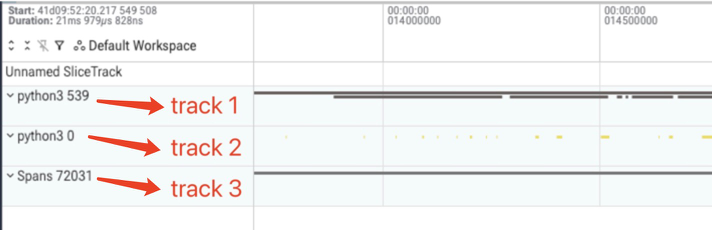

- **track 1** is your main Python process running on CPU. Expand the track and you will see two separate sub-tracks for two threads: the main thread running the forward pass, and a PyTorch-launched thread for its autograd engine runnning the backward pass.
> Note that at the top of the main thread subtrack you might see a long stack of function calls starting with `IPython`, `ipykernel`, etc. These functions are related to the colab notebook environment, so it's safe to ignore them. Pay attention to the lower part of the stack starting with `torch`.

- **track 2** records the activity on GPU like computation and data copy. These operations are usually launched by corresponding CPU calls, which will be visualized with an arrow when you click on a GPU operation.

- **track 3** is triggered by the profiler itself and contains little information to look into. You can safely ignore it.

### Question 3

First generate the two traces by running the profiler at two batch sizes:

```python
run_profile(hidden_dim=256, batch_size=32,  optim_method="adam")   # -> adam_h=256_bs=32_trace.json
run_profile(hidden_dim=256, batch_size=1024, optim_method="adam")   # -> adam_h=256_bs=1024_trace.json
```

Open `adam_h=256_bs=32_trace.json` and `adam_h=256_bs=1024_trace.json` in Perfetto, then zoom in to **the last step** (you should see a tag like `ProfilerStep#4`). Attach a screenshot of the **GPU track** during **the last step** from each trace. What are the names of the GPU kernels executed during forward and backward passes of the Linear operator? Compare the execution time of GPU kernels from the two traces.


In [ ]:
run_profile(hidden_dim=256, batch_size=32,  optim_method="adam")

In [ ]:
run_profile(hidden_dim=256, batch_size=1024, optim_method="adam")

### Question 4

Generate the memory timelines for an SGD run and an Adam run (this requires a GPU runtime):

```python
run_profile(hidden_dim=256, batch_size=128, optim_method="sgd")    # -> sgd_h=256_bs=128_memory.html
run_profile(hidden_dim=256, batch_size=128, optim_method="adam")   # -> adam_h=256_bs=128_memory.html
```

**Q4.1** Open each `*_memory.html` file in a browser. What are the differences in memory consumption between the two optimizers? Explain the relationship between the sizes of the **parameters**, the **gradients**, and the **optimizer states**. Attach corresponding screenshots of your memory timelines.

**Q4.2** PyTorch's SGD optimizer has an optional `momentum` arg (see the [documentation](https://docs.pytorch.org/docs/2.13/generated/torch.optim.SGD.html)), which adds a momentum term to the optimization algorithm when set to a non-zero number. Overwrite the `make_optimizer` function in the code block below to add a new optimization method, `sgd_momentum`, that uses SGD optimizer with `momentum=0.9` in `make_optimizer`. Run the profiling code with the new optimization method, and compare the memory timeline. What changed, and why? Attach corresponding screenshots of your memory timelines.


In [ ]:
run_profile(hidden_dim=256, batch_size=128, optim_method="sgd")

In [ ]:
run_profile(hidden_dim=256, batch_size=128, optim_method="adam")

In [ ]:
# Overwrite the optimizer factory here:
def make_optimizer(name, params, lr):
    # Factory that maps a string name to a configured PyTorch optimizer.
    name = name.lower()
    if name == "sgd":     return torch.optim.SGD(params, lr=lr)
    if name == "adam":    return torch.optim.Adam(params, lr=lr)
    if name == "adamw":   return torch.optim.AdamW(params, lr=lr)
    if name == "rmsprop": return torch.optim.RMSprop(params, lr=lr)
    ###############################################################################
    # TODO: Add the `sgd_momentum` optimizer here.                                #
    ###############################################################################


    ################################################################################
    #                                 END OF YOUR CODE                             #
    ################################################################################

    raise ValueError(f"unknown optimizer: {name!r}")

# And re-run the profiling code:
run_profile(hidden_dim=256, batch_size=128, optim_method="sgd_momentum")

### Question 5

Measure how the **time of one training step** changes with the batch size. Run the profiler at several batch sizes, for example:

```python
for bs in [32, 128, 512, 2048]:
    run_profile(hidden_dim=256, batch_size=bs, optim_method="adam")
```

**Q5.1** For each batch size, open the trace in Perfetto and measure the wall-clock duration of the **last training step**. Report the step time for each batch size and attach a screenshot of your measurement.
> Hint: Two ways to get the execution time of a certain operation or a tagged period from the trace: 1) hover over the block, or 2) drag to select an arbitrary period and read the measured time from the timeline

**Q5.2** How does the step time change with the batch size? Going from `bs=32` to `bs=2048` increases the input workload by 64×; does the step time increase by anywhere near 64×? Reason about the step time change with what you observe in terms of GPU utilization, CPU activities, and data movements.


In [ ]:
for bs in [32, 128, 512, 2048]:
    run_profile(hidden_dim=256, batch_size=bs, optim_method="adam")